In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

/home/natsalaz/anaconda3/envs/qwen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Text diversity through T-SNE

In [2]:
ROOT_DIR = "."  # root folder
DATASETS = ["./XmoPipe/XmoPipe/texts", "./HumanML3D/HumanML3D/texts", "./Idea400/idea400_txt"]  # subfolders
MAX_CHARS = 2000

USE_PCA = True
PCA_DIMS = 50
PERPLEXITY = 30
SEED = 42

In [3]:
def load_texts(folder):
    texts = []
    for path in glob.glob(os.path.join(folder, "*.txt")):
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            txt = f.read().strip()[:MAX_CHARS]
            if len(txt) > 0:
                texts.append(txt)
    return texts


def tsne_projection(X):
    if USE_PCA:
        X = PCA(n_components=PCA_DIMS, random_state=SEED).fit_transform(X)

    tsne = TSNE(
        n_components=2,
        perplexity=PERPLEXITY,
        init="pca",
        learning_rate=200,
        n_iter_without_progress=5,
        random_state=SEED,
    )
    return tsne.fit_transform(X)

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")

./XmoPipe/XmoPipe/texts: 341510 texts


Batches: 100%|██████████| 10673/10673 [03:13<00:00, 55.08it/s]


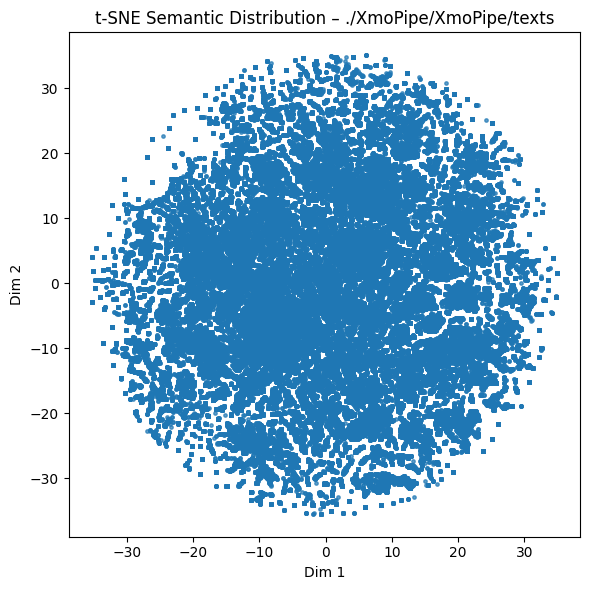

./HumanML3D/HumanML3D/texts: 29232 texts


Batches: 100%|██████████| 914/914 [00:50<00:00, 18.17it/s]


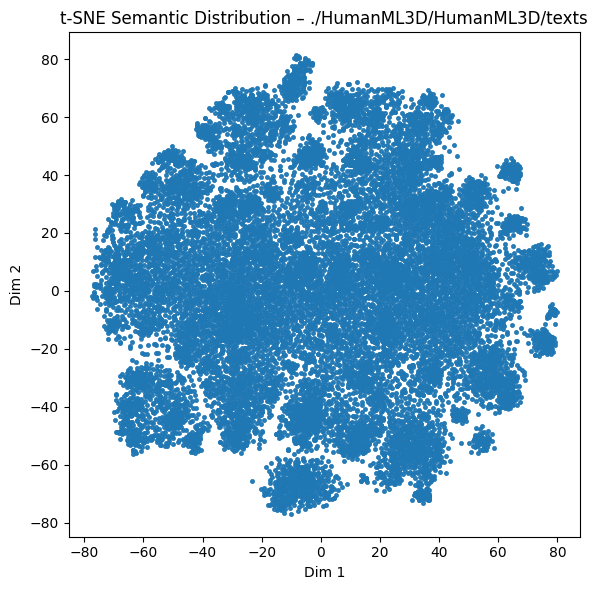

./Idea400/idea400_txt: 12042 texts


Batches: 100%|██████████| 377/377 [00:05<00:00, 63.96it/s]


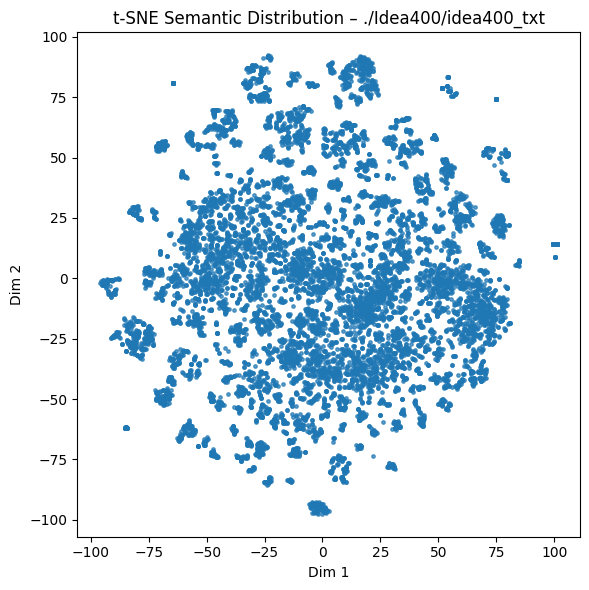

In [ ]:
all_embeddings = []
all_labels = []

for name in DATASETS:
    folder = os.path.join(ROOT_DIR, name)
    texts = load_texts(folder)

    print(f"{name}: {len(texts)} texts")

    embeddings = model.encode(
        texts, batch_size=32, normalize_embeddings=True, show_progress_bar=True
    )

    emb_2d = tsne_projection(embeddings)

    plt.figure(figsize=(6, 6))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=6, alpha=0.7)
    plt.title(f"t-SNE Semantic Distribution – {name}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()

    all_embeddings.append(embeddings)
    all_labels.extend([name] * len(embeddings))

In [6]:
X_all = np.concatenate(all_embeddings, axis=0)
labels = np.array(all_labels)
X_all_2d = tsne_projection(X_all)

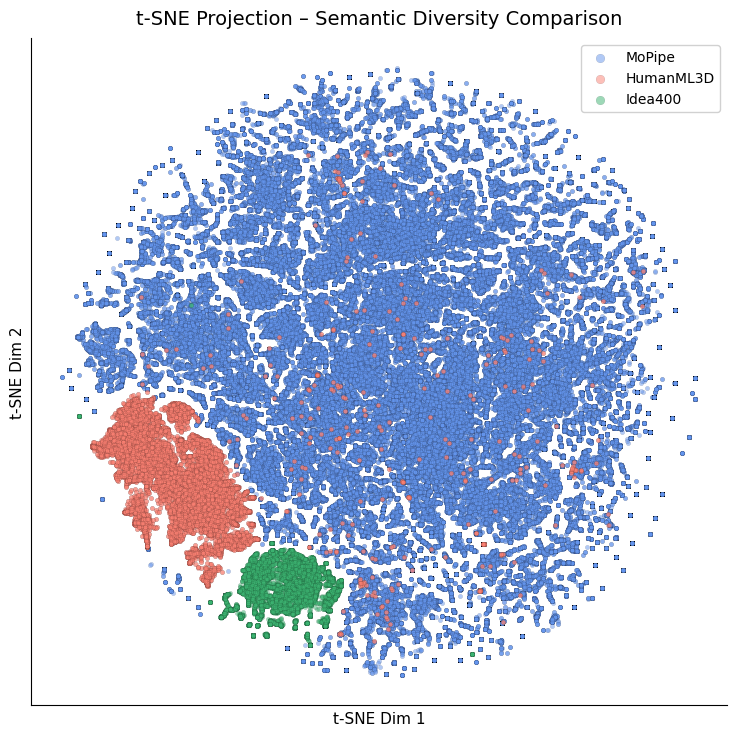

In [7]:
colors = {

    
    DATASETS[0]: "cornflowerblue",
    DATASETS[1]: "salmon",
    DATASETS[2]: "mediumseagreen",
}
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

plt.figure(figsize=(7.5, 7.5))

pretty_names = {
    DATASETS[0]: "MoPipe",
    DATASETS[1]: "HumanML3D",
    DATASETS[2]: "Idea400",
}
for name in DATASETS:
    idx = labels == name
    plt.scatter(
        X_all_2d[idx, 0],
        X_all_2d[idx, 1],
        s=10,
        alpha=0.5,
        color=colors[name],
        edgecolors="black",
        linewidths=0.1,
        label=pretty_names[name],
    )

plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.9,
    markerscale=2,
    fontsize=10,
)

plt.title("t-SNE Projection – Semantic Diversity Comparison", fontsize=14, pad=10)
plt.xlabel("t-SNE Dim 1", fontsize=11)
plt.ylabel("t-SNE Dim 2", fontsize=11)

plt.xticks([])
plt.yticks([])

plt.grid(False)
plt.tight_layout()
plt.show()

# Text classification

In [5]:
from transformers import pipeline
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from datasets import Dataset

In [6]:
CATEGORIES = ["Outdoor activities", "Sports", "Daily life activities", "Work"]

In [7]:
classifier = pipeline(
    "zero-shot-classification",
    model="valhalla/distilbart-mnli-12-1",
    device=0,
)

Device set to use cuda:0


In [8]:
all_results = []

for name in DATASETS:
    print(f"Processing dataset: {name}")
    folder = os.path.join(ROOT_DIR, name)

    texts = load_texts(folder)

Processing dataset: ./XmoPipe/XmoPipe/texts
Processing dataset: ./HumanML3D/HumanML3D/texts
Processing dataset: ./Idea400/idea400_txt


In [9]:
dataset = Dataset.from_dict({"text": texts})

In [10]:
def classify_with_progress(
    texts, classifier, categories, batch_size=32, chunk_size=1024
):
    results = []

    for i in tqdm(range(0, len(texts), chunk_size), desc="Classifying"):
        chunk = texts[i : i + chunk_size]

        outputs = classifier(
            chunk, candidate_labels=categories, batch_size=batch_size, truncation=True
        )

        for text, out in zip(chunk, outputs):
            results.append(
                {"text": text, "category": out["labels"][0], "score": out["scores"][0]}
            )

    return results

In [12]:
xmopipe = "./XmoPipe/XmoPipe/texts"
folder = os.path.join(ROOT_DIR, xmopipe)
texts = load_texts(folder)

results = classify_with_progress(
    texts, classifier, CATEGORIES, batch_size=64, chunk_size=512
)

KeyboardInterrupt: 

In [ ]:
print results

In [ ]:
final_results = []

for text, res in zip(texts, results):
    final_results.append(
        {"text": text, "category": res["labels"][0], "score": res["scores"][0]}
    )

KeyError: 'labels'

In [ ]:
import pandas as pd

df = pd.DataFrame(all_results)
df.head()